# FABLEN demo
## 1 Parity Task

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import train_test_split
import fablen
from fablen import FABLENLayer, FABLENStack, sparsemax
# =============================================================================
# TRAINING LOOP: PARITY ONLY
# =============================================================================

print("="*60)
print("TRAINING: 10-BIT PARITY (FABLEN)")
print("="*60)

# Hyperparameters
N_BITS = 10
HIDDEN_DIM = 32
N_LAYERS = 4
EPOCHS = 500
LR = 0.02
BATCH_SIZE = None # Using full batch for parity as per original logic, can be modified

# Data Generation
torch.manual_seed(0)
X_par = torch.randint(0, 2, (5000, N_BITS)).float()
y_par = (X_par.sum(1) % 2).long()

# Split
X_ptr, X_pte, y_ptr, y_pte = train_test_split(X_par, y_par, test_size=0.2, random_state=42)

# Model Init
model_parity = FABLENStack(in_dim=N_BITS, logic_dim=HIDDEN_DIM, out_dim=2, n_layers=N_LAYERS)
total_params = sum(p.numel() for p in model_parity.parameters() if p.requires_grad)
print(f"Model Parameters: {total_params:,}")

optimizer_p = torch.optim.Adam(model_parity.parameters(), lr=LR)
losses_p = []

# Training
for epoch in range(EPOCHS):
    model_parity.train()
    optimizer_p.zero_grad()
    
    # Forward pass
    logits = model_parity(X_ptr)
    loss = F.cross_entropy(logits, y_ptr)
    
    # Backward pass
    loss.backward()
    optimizer_p.step()
    losses_p.append(loss.item())
    # Logging
    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        model_parity.eval()
        with torch.no_grad():
            preds = model_parity(X_pte)
            acc = (preds.argmax(1) == y_pte).float().mean().item()
        print(f"Epoch {epoch:>4} | Loss: {loss.item():.4f} | Test Acc: {acc:.4f}")

print("\nTraining Complete.")

TRAINING: 10-BIT PARITY (FABLEN)
Model Parameters: 11,298
Epoch    0 | Loss: 0.7887 | Test Acc: 0.5100
Epoch   50 | Loss: 0.6916 | Test Acc: 0.4960
Epoch  100 | Loss: 0.6902 | Test Acc: 0.4980
Epoch  150 | Loss: 0.4110 | Test Acc: 0.7460
Epoch  200 | Loss: 0.1287 | Test Acc: 0.9540
Epoch  250 | Loss: 0.0576 | Test Acc: 0.9760
Epoch  300 | Loss: 0.0324 | Test Acc: 0.9870
Epoch  350 | Loss: 0.0221 | Test Acc: 0.9950
Epoch  400 | Loss: 0.0094 | Test Acc: 0.9990
Epoch  450 | Loss: 0.0064 | Test Acc: 0.9990
Epoch  499 | Loss: 0.0053 | Test Acc: 0.9990

Training Complete.



  LAYER 0 DIAGNOSTICS

[Op Distribution] what logical tools neurons prefer:
  Op          Count   % neurons  Bar
  ---------------------------------------------
  A_AND_NOT_B      1        3.1%  █
  A               3        9.4%  ███
  NOT_A_AND_B      4       12.5%  █████
  B               3        9.4%  ███
  XOR             8       25.0%  ██████████
  XNOR            7       21.9%  ████████
  NOT_B           3        9.4%  ███
  NOT_A           3        9.4%  ███

[Op Confidence] how committed neurons are to their dominant op:
  <25%        20 neurons  ██████████████████
  25-50%       7 neurons  ██████
  50-75%       5 neurons  ████
  75-90%       0 neurons  
  >90%         0 neurons  

[Selection Sparsity]
  Mean selection entropy : 0.243  (0=one-hot, 3.47=uniform)
  Max selection entropy  : 1.776
  Sparsity score         : 0.930  (1=fully discrete, 0=diffuse)

[Sharpness (gamma)] how binary the outputs are:
  Mean  : 2.387
  Median: 2.299
  Max   : 5.147
  Neurons with gamma > 2

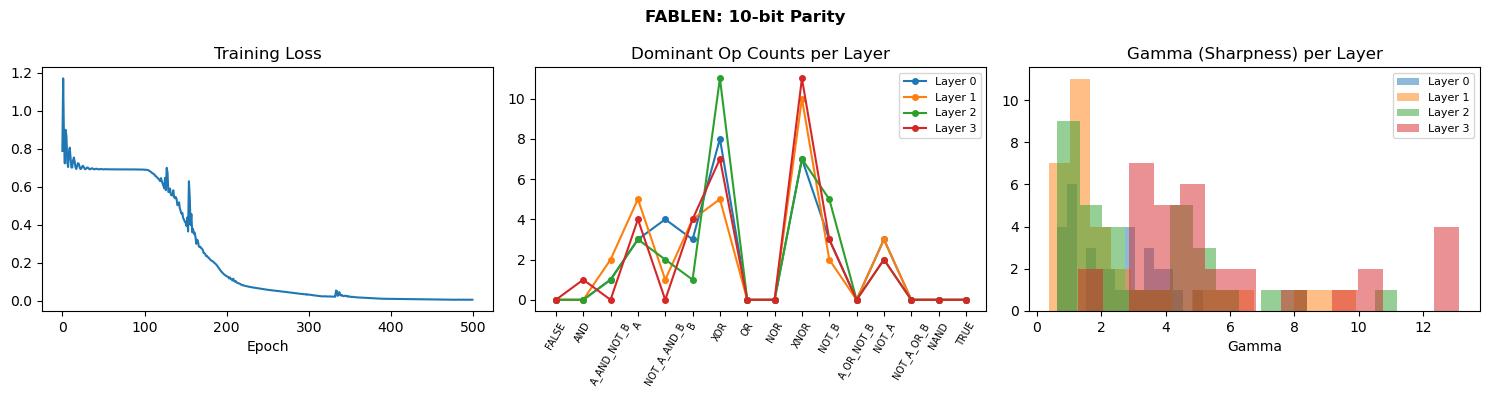

In [8]:
# =============================================================================
# Diagnostics & Plots
# =============================================================================
import matplotlib.pyplot as plt

# DIAGNOSTICS HELPERS 
OP_NAMES = [
    "FALSE", "AND", "A_AND_NOT_B", "A",
    "NOT_A_AND_B", "B", "XOR", "OR",
    "NOR", "XNOR", "NOT_B", "A_OR_NOT_B",
    "NOT_A", "NOT_A_OR_B", "NAND", "TRUE",
]

def dominant_op_per_neuron(layer):
    """Returns the argmax op index and name for each neuron in a layer."""
    with torch.no_grad():
        op_weights = F.softmax(layer.op_logits, dim=-1).cpu().numpy()
    dominant_idx = op_weights.argmax(axis=-1)
    dominant_prob = op_weights.max(axis=-1)
    return dominant_idx, dominant_prob, op_weights

def sparsity_of_selection(layer):
    """
    Measures how 'discrete' the selection is.
    A pure one-hot has entropy=0; uniform has entropy=log(in_dim).
    Returns mean entropy of selection weights across neurons and slots.
    """
    with torch.no_grad():
        sel = sparsemax(layer.sel_logits, dim=-1).cpu()  # [out, 2, in]
        # Entropy: -sum(p * log(p+eps))
        entropy = -(sel * torch.log(sel + 1e-9)).sum(dim=-1)  # [out, 2]
    return entropy.mean().item(), entropy.max().item()

def print_layer_diagnostics(model, layer_idx=0):
    layer = model.layers[layer_idx]
    dominant_idx, dominant_prob, op_weights = dominant_op_per_neuron(layer)

    print(f"\n{'='*60}")
    print(f"  LAYER {layer_idx} DIAGNOSTICS")
    print(f"{'='*60}")

    # --- Op distribution summary ---
    print(f"\n[Op Distribution] what logical tools neurons prefer:")
    op_counts = np.bincount(dominant_idx, minlength=16)
    print(f"  {'Op':<10} {'Count':>6}  {'% neurons':>10}  {'Bar'}")
    print(f"  {'-'*45}")
    for i, (name, count) in enumerate(zip(OP_NAMES, op_counts)):
        if count > 0:
            bar = '█' * int(count / len(dominant_idx) * 40)
            print(f"  {name:<10} {count:>6}  {100*count/len(dominant_idx):>9.1f}%  {bar}")

    # --- Confidence in op choice ---
    print(f"\n[Op Confidence] how committed neurons are to their dominant op:")
    bins = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ['<25%', '25-50%', '50-75%', '75-90%', '>90%']
    hist, _ = np.histogram(dominant_prob, bins=bins)
    for label, count in zip(labels, hist):
        bar = '█' * int(count / len(dominant_prob) * 30)
        print(f"  {label:<8} {count:>5} neurons  {bar}")

    # --- Selection sparsity ---
    mean_ent, max_ent = sparsity_of_selection(layer)
    max_possible = np.log(layer.in_dim)
    print(f"\n[Selection Sparsity]")
    print(f"  Mean selection entropy : {mean_ent:.3f}  (0=one-hot, {max_possible:.2f}=uniform)")
    print(f"  Max selection entropy  : {max_ent:.3f}")
    print(f"  Sparsity score         : {1 - mean_ent/max_possible:.3f}  (1=fully discrete, 0=diffuse)")

    # --- Sharpness ---
    with torch.no_grad():
        gamma = torch.exp(layer.log_gamma).cpu().numpy()
    print(f"\n[Sharpness (gamma)] how binary the outputs are:")
    print(f"  Mean  : {gamma.mean():.3f}")
    print(f"  Median: {np.median(gamma):.3f}")
    print(f"  Max   : {gamma.max():.3f}")
    sharp_frac = (gamma > 2.0).mean()
    print(f"  Neurons with gamma > 2 (noticeably discretizing): {100*sharp_frac:.1f}%")

def print_interesting_neurons(model, layer_idx=0, n=5):
    """Print a few neurons with high op confidence as concrete examples."""
    layer = model.layers[layer_idx]
    dominant_idx, dominant_prob, op_weights = dominant_op_per_neuron(layer)

    with torch.no_grad():
        sel = sparsemax(layer.sel_logits, dim=-1).cpu().numpy()  # [out, 2, in]
        gamma = torch.exp(layer.log_gamma).cpu().numpy()

    # Pick top-n by op confidence
    top_neurons = np.argsort(dominant_prob)[::-1][:n]

    print(f"\n{'='*60}")
    print(f"  TOP {n} MOST COMMITTED NEURONS (layer {layer_idx})")
    print(f"{'='*60}")
    for ni in top_neurons:
        op_name = OP_NAMES[dominant_idx[ni]]
        conf = dominant_prob[ni]
        g = gamma[ni]
        # Top-2 selected input indices per slot
        top_a = np.argsort(sel[ni, 0])[::-1][:2]
        top_b = np.argsort(sel[ni, 1])[::-1][:2]
        print(f"\n  Neuron {ni:>4}: op={op_name:<8} conf={conf:.2f}  gamma={g:.2f}")
        print(f"    Input A → feature {top_a[0]:>3} ({sel[ni,0,top_a[0]]:.2f}) "
              f"+ feature {top_a[1]:>3} ({sel[ni,0,top_a[1]]:.2f}) ...")
        print(f"    Input B → feature {top_b[0]:>3} ({sel[ni,1,top_b[0]]:.2f}) "
              f"+ feature {top_b[1]:>3} ({sel[ni,1,top_b[1]]:.2f}) ...")


# Diagnostics
model_parity.eval()
print_layer_diagnostics(model_parity, layer_idx=0)
print_layer_diagnostics(model_parity, layer_idx=3)
print_interesting_neurons(model_parity, layer_idx=0, n=5)

# Check if XOR dominates on parity 
print(f"\n[Parity XOR Check]")
for li in range(4):
    dom_idx_p, dom_prob_p, _ = dominant_op_per_neuron(model_parity.layers[li])
    xor_frac = (dom_idx_p == 6).mean()  # op 6 = XOR
    print(f"  Layer {li}: XOR is dominant op in {100*xor_frac:.1f}% of neurons "
          f"(mean conf: {dom_prob_p.mean():.2f})")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("FABLEN: 10-bit Parity", fontweight='bold')

axes[0].plot(losses_p)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")

# Op distribution across all 4 layers
for li in range(4):
    dom_idx_p, _, _ = dominant_op_per_neuron(model_parity.layers[li])
    op_counts_p = np.bincount(dom_idx_p, minlength=16)
    axes[1].plot(op_counts_p, label=f'Layer {li}', marker='o', markersize=4)
axes[1].set_xticks(range(16))
axes[1].set_xticklabels(OP_NAMES, rotation=60, fontsize=7)
axes[1].set_title("Dominant Op Counts per Layer")
axes[1].legend(fontsize=8)

# Sharpness per layer
for li in range(4):
    with torch.no_grad():
        gamma_p = torch.exp(model_parity.layers[li].log_gamma).cpu().numpy()
    axes[2].hist(gamma_p, bins=15, alpha=0.5, label=f'Layer {li}')
axes[2].set_title("Gamma (Sharpness) per Layer")
axes[2].set_xlabel("Gamma")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# Discovered and Learnt Ops Visualization

Reading this diagram: Each layer displays up to max_neurons representative neurons (evenly subsampled from the full layer width). Edges show the strongest input connection per slot, mapped to the nearest displayed node in the previous layer; not the exact learned connection. Increase max_neurons to reduce approximation, at the cost of a denser graph. For small input dimensions (e.g. N=10 parity), set max_inputs=N to show all input nodes and get accurate edge origins.

Input connection density reflects learned selection frequency across training, not information content. Boundary features may appear over-represented due to initialization asymmetries in the input projection rather than task-relevant structure. For tasks where all inputs are equally informative (e.g. parity), this is expected.



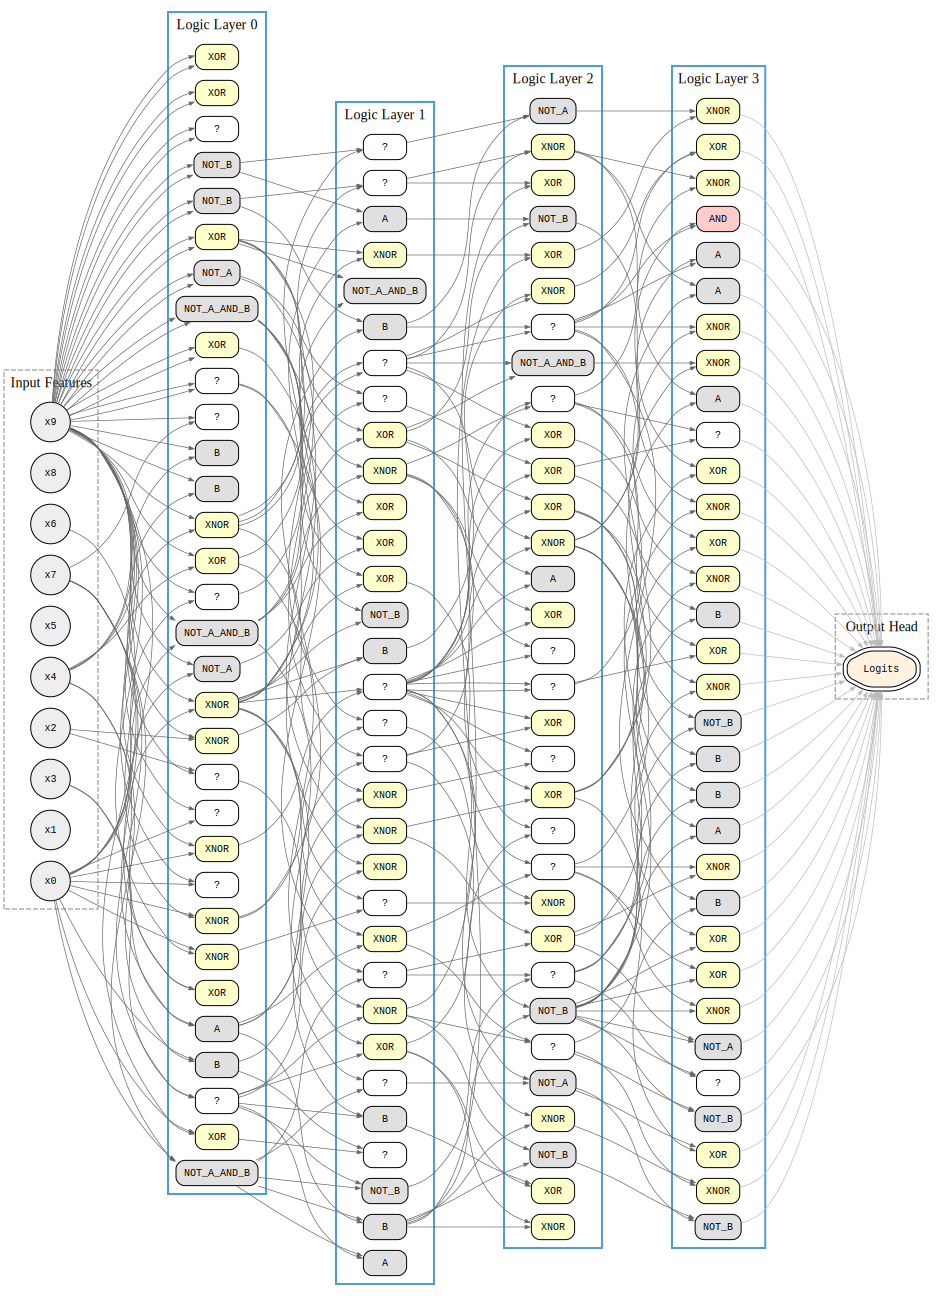

In [9]:
import graphviz
import numpy as np
 
# Color scheme by op family; helps visually distinguish op types at a glance.
# XOR/XNOR: yellow (parity-relevant)  AND-family: red  OR-family: green
# Negations/projections: grey  Constants: dark grey
_OP_COLORS = {
    frozenset([6, 9]):          "#ffffcc",   # XOR, XNOR
    frozenset([1, 14, 2, 11]):  "#ffcccc",   # AND, NAND, A∧¬B, A∨¬B
    frozenset([7, 8, 13]):      "#ccffcc",   # OR, NOR, ¬A∨B
    frozenset([3, 4, 5, 10, 12]): "#e0e0e0", # A, B, ¬A∧B, ¬B, ¬A
    frozenset([0, 15]):         "#cccccc",   # FALSE, TRUE
}
 
# Confidence threshold below which a neuron is shown as "?" (uncommitted).
# Set to None to always show the argmax op regardless of confidence.
CONFIDENCE_THRESHOLD = 0.15
 
 
def _op_color(op_idx: int) -> str:
    for key, color in _OP_COLORS.items():
        if op_idx in key:
            return color
    return "#ffffff"
 
 
def _representative_indices(total: int, max_shown: int) -> list:
    """
    Pick up to max_shown evenly-spaced indices from [0, total).
    Always includes index 0 and total-1.
    """
    if total <= max_shown:
        return list(range(total))
    step = total / max_shown
    indices = sorted(set(
        [0] + [int(i * step) for i in range(1, max_shown)] + [total - 1]
    ))
    return indices
 
 
def visualize_circuit(
    model, 
    filename="fablen_circuit", 
    format="png", 
    max_inputs=10, 
    max_neurons=32
):
    dot = graphviz.Digraph(comment='FABLEN Circuit', format=format)
    
    # Global Attributes for Horizontal Flow 
    dot.attr(rankdir='LR')
    dot.attr(nodesep='0.15', ranksep='1.2')
    dot.attr('node', fontname='Courier', fontsize='10', style='rounded,filled')
    dot.attr('edge', color='#666666', penwidth='0.7', arrowsize='0.5')

    # 1. Input Layer Subgraph
    in_dim = model.input_proj.in_features
    input_indices = _representative_indices(in_dim, max_inputs)
    
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='Input Features', style='dashed', color='#888888')
        for i in input_indices:
            c.node(f"In_{i}", f"x{i}", shape="circle", fillcolor="#eeeeee", width='0.3', height='0.3')

    # Track drawn nodes for connectivity
    drawn_nodes_per_layer = { -1: [f"In_{i}" for i in input_indices] } 

    # 2. Logic Stack Layers
    for l_idx, layer in enumerate(model.layers):
        layer_nodes = []
        with torch.no_grad():
            sel_weights = sparsemax(layer.sel_logits, dim=-1).cpu().numpy()
            op_weights  = F.softmax(layer.op_logits, dim=-1).cpu().numpy()
            dominant_ops = op_weights.argmax(axis=-1)
            dom_prob     = op_weights.max(axis=-1)
            
        out_dim = layer.out_dim
        neuron_indices = _representative_indices(out_dim, max_neurons)

        with dot.subgraph(name=f'cluster_L{l_idx}') as c:
            c.attr(label=f'Logic Layer {l_idx}', color='#4C9BE8', penwidth='2')
            
            for n_idx in neuron_indices:
                node_id = f"L{l_idx}_N{n_idx}"
                
                # --- Confidence Threshold & Coloring Logic ---
                conf = dom_prob[n_idx]
                if CONFIDENCE_THRESHOLD is not None and conf < CONFIDENCE_THRESHOLD:
                    label, color = "?", "#ffffff"
                else:
                    op_i = dominant_ops[n_idx]
                    label = OP_NAMES[op_i]
                    color = _op_color(op_i)
                
                c.node(node_id, label, shape="box", fillcolor=color, width='0.6', height='0.35')
                layer_nodes.append(node_id)
                
                # Connect to previous layer exactly as old code did
                for slot in [0, 1]:
                    w = sel_weights[n_idx, slot, :]
                    top_in = np.argmax(w)
                    
                    if w[top_in] > 0.05:
                        if l_idx == 0:
                            closest_idx = min(input_indices, key=lambda x: abs(x - top_in))
                            src_id = f"In_{closest_idx}"
                        else:
                            prev_out_dim = model.layers[l_idx-1].out_dim
                            prev_indices = _representative_indices(prev_out_dim, max_neurons)
                            closest_idx  = min(prev_indices, key=lambda x: abs(x - top_in))
                            src_id = f"L{l_idx-1}_N{closest_idx}"
                        
                        dot.edge(src_id, node_id)

        drawn_nodes_per_layer[l_idx] = layer_nodes

    # 3. Output Head
    with dot.subgraph(name='cluster_output') as c:
        c.attr(label='Output Head', style='dashed', color='#888888')
        c.node("Out", "Logits", shape="doubleoctagon", fillcolor="#fff3e0")

    # Final logic layer to output mapping
    last_layer_idx = len(model.layers) - 1
    for node in drawn_nodes_per_layer[last_layer_idx]:
        dot.edge(node, "Out", color='#bbbbbb')

    dot.render(filename, cleanup=True)
    return dot

# Usage:
viz = visualize_circuit(model_parity, filename="lng_full_circuit_parity")
viz

# FABLEN demo
## 2 SCIKIT-LEARN DIGITS Classification Task


  FABLEN: DIGITS CLASSIFICATION
Params: 151,434
  Epoch   0 | Loss: 2.6676 | Test Acc: 0.0778
  Epoch  20 | Loss: 0.9402 | Test Acc: 0.7556
  Epoch  40 | Loss: 0.3153 | Test Acc: 0.9167
  Epoch  60 | Loss: 0.1536 | Test Acc: 0.9472
  Epoch  80 | Loss: 0.0805 | Test Acc: 0.9583
  Epoch 100 | Loss: 0.0335 | Test Acc: 0.9667
  Epoch 120 | Loss: 0.0116 | Test Acc: 0.9667
  Epoch 140 | Loss: 0.0049 | Test Acc: 0.9667
  Epoch 160 | Loss: 0.0027 | Test Acc: 0.9667
  Epoch 180 | Loss: 0.0018 | Test Acc: 0.9639

  LAYER 0 DIAGNOSTICS

[Op Distribution] what logical tools neurons prefer:
  Op          Count   % neurons  Bar
  ---------------------------------------------
  A              11        8.6%  ███
  B              13       10.2%  ████
  XOR            48       37.5%  ███████████████
  OR              1        0.8%  
  XNOR           42       32.8%  █████████████
  NOT_B           8        6.2%  ██
  NOT_A           5        3.9%  █

[Op Confidence] how committed neurons are to their d

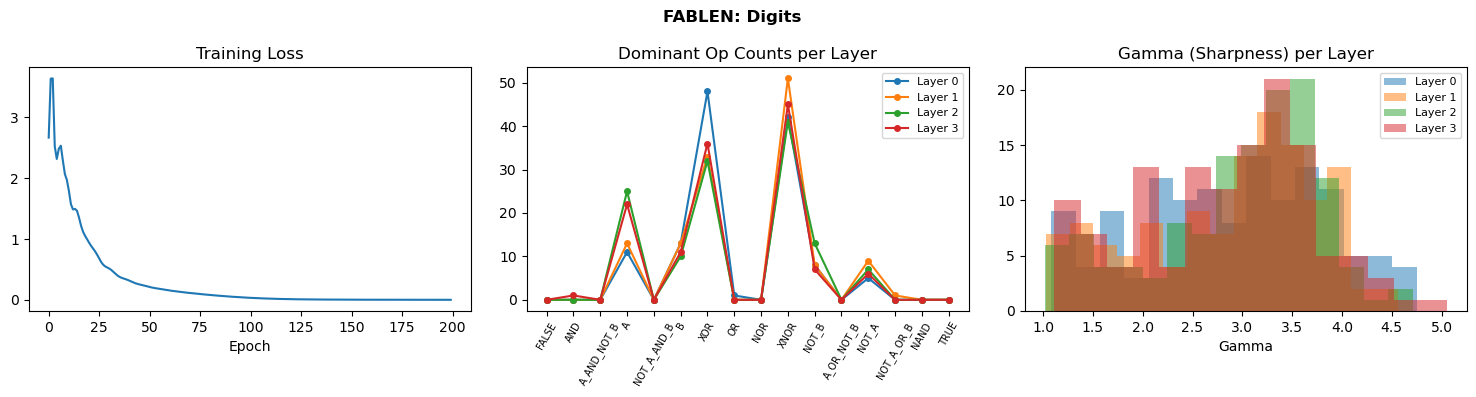

In [ ]:
# =============================================================================
# SCIKIT-LEARN DIGITS
# =============================================================================

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


print("\n" + "="*60)
print("  FABLEN: DIGITS CLASSIFICATION")
print("="*60)

digits = load_digits()
X = MinMaxScaler().fit_transform(digits.data)
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_t  = torch.tensor(X_train, dtype=torch.float32)
y_t  = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.long)

model_digits = FABLENStack(in_dim=64, logic_dim=128, out_dim=10, n_layers=4)
print(f"Params: {sum(p.numel() for p in model_digits.parameters() if p.requires_grad):,}")

optimizer = torch.optim.Adam(model_digits.parameters(), lr=0.01)
losses_d, accs_d = [], []

for epoch in range(200):
    model_digits.train()
    optimizer.zero_grad()
    loss = F.cross_entropy(model_digits(X_t), y_t)
    loss.backward()
    optimizer.step()
    losses_d.append(loss.item())

    if epoch % 20 == 0:
        model_digits.eval()
        with torch.no_grad():
            acc = (model_digits(X_te).argmax(1) == y_te).float().mean().item()
        accs_d.append(acc)
        print(f"  Epoch {epoch:>3} | Loss: {loss.item():.4f} | Test Acc: {acc:.4f}")

# Diagnostics
model_digits.eval()
print_layer_diagnostics(model_digits, layer_idx=0)
print_layer_diagnostics(model_digits, layer_idx=1)
print_interesting_neurons(model_digits, layer_idx=0, n=5)

# Plots

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("FABLEN: Digits", fontweight='bold')
axes[0].plot(losses_d)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")

# Op distribution across all 4 layers
for li in range(4):
    dom_idx_p, _, _ = dominant_op_per_neuron(model_digits.layers[li])
    op_counts_p = np.bincount(dom_idx_p, minlength=16)
    axes[1].plot(op_counts_p, label=f'Layer {li}', marker='o', markersize=4)
axes[1].set_xticks(range(16))
axes[1].set_xticklabels(OP_NAMES, rotation=60, fontsize=7)
axes[1].set_title("Dominant Op Counts per Layer")
axes[1].legend(fontsize=8)

# Sharpness per layer
for li in range(4):
    with torch.no_grad():
        gamma_p = torch.exp(model_digits.layers[li].log_gamma).cpu().numpy()
    axes[2].hist(gamma_p, bins=15, alpha=0.5, label=f'Layer {li}')
axes[2].set_title("Gamma (Sharpness) per Layer")
axes[2].set_xlabel("Gamma")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Discovered and Learnt Ops Visualization

Reading this diagram: Each layer displays up to max_neurons representative neurons (evenly subsampled from the full layer width). Edges show the strongest input connection per slot, mapped to the nearest displayed node in the previous layer; not the exact learned connection. Increase max_neurons to reduce approximation, at the cost of a denser graph. For small input dimensions (e.g. N=10 parity), set max_inputs=N to show all input nodes and get accurate edge origins.

Input connection density reflects learned selection frequency across training, not information content. Boundary features may appear over-represented due to initialization asymmetries in the input projection rather than task-relevant structure. For tasks where all inputs are equally informative (e.g. parity), this is expected.



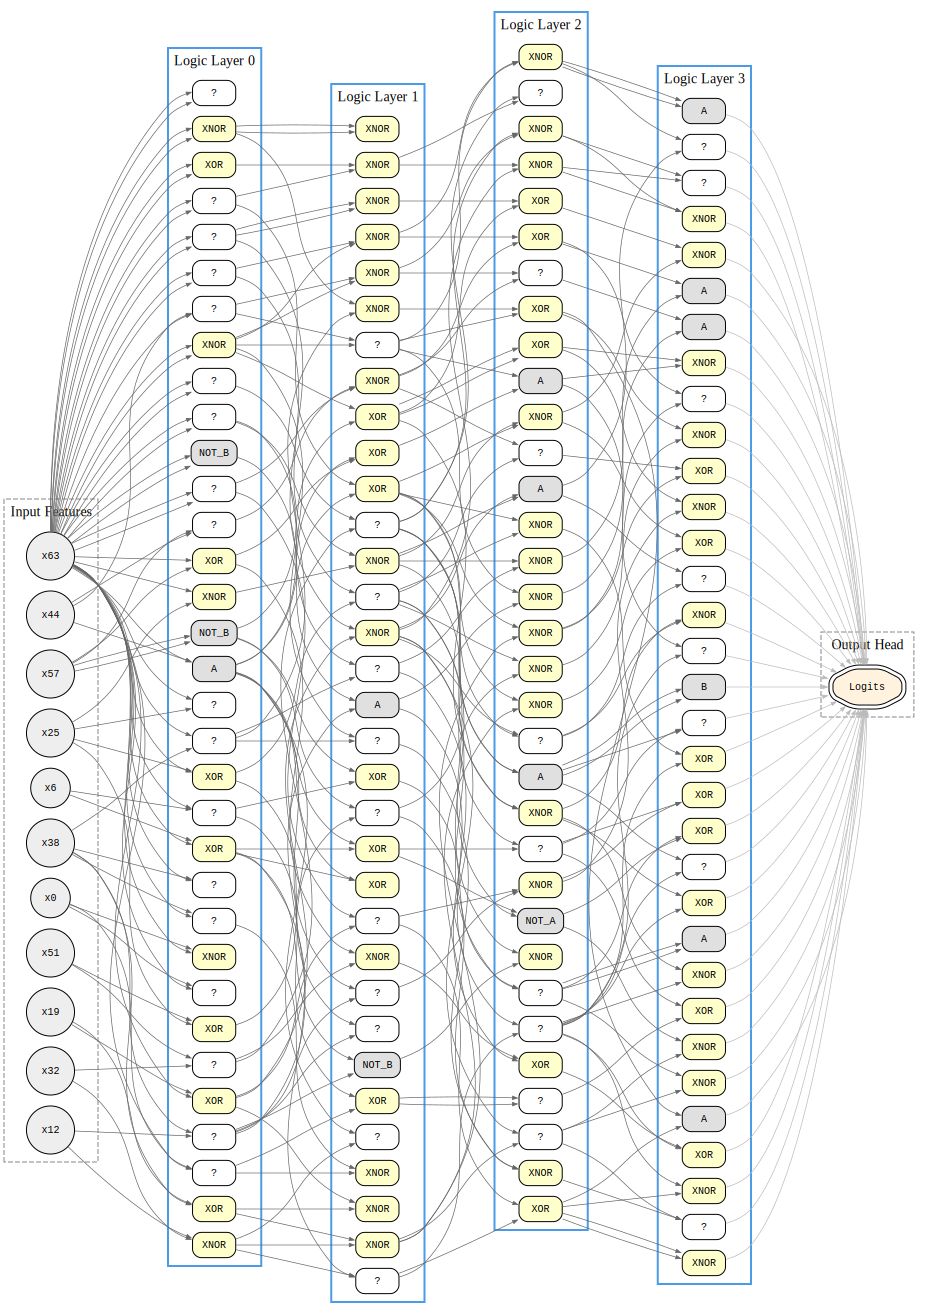

In [5]:
viz = visualize_circuit(model_digits, filename="lng_full_circuit_digits")
viz